In [1]:
import sys
from pathlib import Path

# Make the mobility package importable when running from notebooks/
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd

from mobility.config import MobilityConfig
from mobility import geometry, transitions, stats

DATA_DIR = REPO_ROOT / "data"
OUTPUTS_DIR = REPO_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root :", REPO_ROOT)
print("Data dir  :", DATA_DIR)

Repo root : /home/joc/code/two-scales-of-mobility
Data dir  : /home/joc/code/two-scales-of-mobility/data


In [2]:
cfg = MobilityConfig()
np.random.seed(cfg.seed)
print(cfg)

MobilityConfig(seed=42, p_threshold=0.0, top_k=None, task_policy='all', centroid_method='median_xy', sensitivity_grid=((0.0001, 3), (0.0005, 3), (0.001, 3), (0.002, 3), (0.001, 1), (0.001, 5), (0.001, 10)))


In [3]:
df_occ = geometry.load_occupations(DATA_DIR / "occupation_embeddings_polar_scaled.csv")
df_tasks = geometry.load_tasks(DATA_DIR / "task_embeddings_polar_scaled.csv")

print(f"Occupations (O*NET-detailed): {len(df_occ)}")
print(f"Tasks (O*NET-detailed)      : {len(df_tasks)}")

df_occ.head(3)

Occupations (O*NET-detailed): 878
Tasks (O*NET-detailed)      : 17606


,onet_code,xi,chi,Title,Job Family,sector_zone,onet_full,x,y,soc2018
0,11-1011.00,0.043075,0.428001,Chief Executives,Management,00-Z2,11-1011.00,0.427604,0.018430,11-1011
1,11-1011.03,0.733850,0.568901,Chief Sustainability Officers,Management,04-Z2,11-1011.03,0.422467,0.381012,11-1011
2,11-1021.00,6.010791,0.224539,General and Operations Managers,Management,34-Z1,11-1021.00,0.216261,-0.060410,11-1021


In [4]:
df_soc_centres = geometry.build_soc_centres(df_occ)
df_task_radii = geometry.build_task_radii(df_occ, df_tasks, task_policy=cfg.task_policy)

print(f"SOC2018 centres   : {len(df_soc_centres)}")
print(f"SOC2018 with radii: {len(df_task_radii)}")

df_soc_centres.head(3)

SOC2018 centres   : 765
SOC2018 with radii: 765


,soc2018,x_soc,y_soc,n_onet_detailed,xi_soc,chi_soc
0,11-1011,0.425035,0.199721,2,0.439273,0.469621
1,11-1021,0.216261,-0.060410,1,6.010791,0.224539
2,11-2011,0.351489,-0.033891,1,6.187060,0.353119


In [5]:
df_ipums = transitions.load_ipums_transitions(DATA_DIR / "transitions_20_24.csv")
F, P, soc_index = transitions.build_transition_matrix(df_ipums)

print(f"IPUMS rows used : {len(df_ipums)}")
print(f"SOC universe (N): {len(soc_index)}")
print(f"Nonzero flows   : {int(np.count_nonzero(F))}")
print(f"Rows with sum>0 : {int(np.sum(F.sum(axis=1) > 0))}")

IPUMS rows used : 38697
SOC universe (N): 313
Nonzero flows   : 12282
Rows with sum>0 : 313


In [6]:
df_edges = transitions.build_edges(
    P=P,
    soc_index=soc_index,
    df_soc_centres=df_soc_centres,
    df_task_radii=df_task_radii,
    p_threshold=cfg.p_threshold,
    top_k=cfg.top_k,
)

print(f"Edges total    : {len(df_edges)}")
print(f"Sources covered: {df_edges['src_soc2018'].nunique()}")
print(f"Targets covered: {df_edges['tgt_soc2018'].nunique()}")

df_edges.head(5)

Edges total    : 10551
Sources covered: 296
Targets covered: 296


,src_soc2018,tgt_soc2018,wP,d_xy,R_src_task_rms,u_R,x_src,y_src,x_tgt,y_tgt
0,11-1011,11-1021,0.057640,0.333549,0.239519,1.392578,0.425035,0.199721,0.216261,-0.060410
1,11-1011,11-2011,0.005707,0.244916,0.239519,1.022532,0.425035,0.199721,0.351489,-0.033891
2,11-1011,11-3021,0.017424,0.147539,0.239519,0.615980,0.425035,0.199721,0.302841,0.117039
3,11-1011,11-3031,0.039638,0.202565,0.239519,0.845714,0.425035,0.199721,0.343143,0.014448
4,11-1011,11-3051,0.005825,0.559278,0.239519,2.335004,0.425035,0.199721,-0.119360,0.327886


In [7]:
# Quick weighted summaries to compare against the old notebook's KPIs.
w = df_edges["wP"].to_numpy(float)
d = df_edges["d_xy"].to_numpy(float)
u_R = df_edges["u_R"].to_numpy(float)

summary = pd.DataFrame([{
    "n_edges": len(df_edges),
    "w_sum": float(w.sum()),
    "d_median_w": stats.wquantile(d, w, 0.50),
    "d_p75_w":    stats.wquantile(d, w, 0.75),
    "d_p90_w":    stats.wquantile(d, w, 0.90),
    "u_R_median_w": stats.wquantile(u_R, w, 0.50),
}])
summary

,n_edges,w_sum,d_median_w,d_p75_w,d_p90_w,u_R_median_w
0,10551,275.968766,0.281343,0.456903,0.647861,1.029133


In [8]:
from mobility import overlap

df_edges_full = overlap.merge_target_radii(df_edges, df_task_radii)
df_edges_full = overlap.add_signed_overlap(df_edges_full)

print(f"Edges with overlap: {df_edges_full['overlap_signed'].notna().sum()}")
print(f"Share with positive overlap (unweighted): "
      f"{(df_edges_full['overlap_signed'] > 0).mean():.3f}")

overlap.overlap_summary(df_edges_full)

Edges with overlap: 10551
Share with positive overlap (unweighted): 0.748


{'n_valid': 10551,
 'pearson_unweighted': -0.9558506847262551,
 'pearson_weighted': np.float64(-0.9469531527866851),
 'share_positive_w': 0.8365227287229869}

In [9]:
w = df_edges_full["wP"].to_numpy(float)
d = df_edges_full["d_xy"].to_numpy(float)
u_R = df_edges_full["u_R"].to_numpy(float)

xs_uR, cdf_uR = stats.weighted_ecdf(u_R, w)
thresholds = [0.10, 0.25, 0.33, 0.50, 1.00, 1.50, 2.00]

kpi_table = pd.DataFrame([{
    "n_edges": len(df_edges_full),
    "d_median": stats.wquantile(d, w, 0.50),
    "d_p75":    stats.wquantile(d, w, 0.75),
    "d_p90":    stats.wquantile(d, w, 0.90),
    "u_R_median": stats.wquantile(u_R, w, 0.50),
    "u_R_p75":    stats.wquantile(u_R, w, 0.75),
    "u_R_p90":    stats.wquantile(u_R, w, 0.90),
    **{f"share_u_R_le_{t:.2f}".replace(".", "p"):
       100.0 * stats.weighted_cdf_at(xs_uR, cdf_uR, t)
       for t in thresholds},
}])

kpi_table.to_csv(TABLES_DIR / "section_3_1_1_kpis.csv", index=False)
kpi_table.T

,0
n_edges,10551.000000
d_median,0.281343
d_p75,0.456903
d_p90,0.647861
u_R_median,1.029133
u_R_p75,1.693855
u_R_p90,2.404778
share_u_R_le_0p10,0.876306
share_u_R_le_0p25,4.829629
share_u_R_le_0p33,8.816309


In [10]:
from mobility import plots

plots.plot_ecdf_absolute(
    df_edges_full,
    FIGURES_DIR / "ecdf_hoplength_abs_weighted.pdf",
)
plots.plot_ecdf_normalised(
    df_edges_full,
    FIGURES_DIR / "ecdf_hoplength_norm_weighted_uR.pdf",
)
plots.plot_overlap_vs_hop(
    df_edges_full,
    FIGURES_DIR / "overlap_vs_hop_uR.pdf",
)
plots.plot_overlap_cdf(
    df_edges_full,
    FIGURES_DIR / "overlap_cdf_uR.pdf",
)

print("Figures written to:", FIGURES_DIR)
for fp in sorted(FIGURES_DIR.glob("*.pdf")):
    print(f"  {fp.name}")

Figures written to: /home/joc/code/two-scales-of-mobility/outputs/figures
  cost_by_K.pdf
  ecdf_hoplength_abs_weighted.pdf
  ecdf_hoplength_norm_weighted_uR.pdf
  gmm_model_selection.pdf
  jobfam_composition_K2.pdf
  jobfam_composition_K6.pdf
  k2_vs_k3_geography.pdf
  k_sweep_geography.pdf
  overlap_cdf_uR.pdf
  overlap_vs_hop_uR.pdf


In [11]:
from mobility import fields as mfields

# Use full edge table (with target radii for completeness; not strictly needed
# for fields but harmless).
edges_arrays = mfields.prepare_edges(df_edges_full)

field_cfg = mfields.FieldConfig(
    bandwidth=0.08,
    n_grid=120,
    batch=1024,
)
grid = mfields.make_grid(field_cfg)

cache_dir = OUTPUTS_DIR / "field_cache"

# Global absolute field
field_global = mfields.compute_or_load(
    name="global_absolute",
    edges=edges_arrays, grid=grid, cfg=field_cfg,
    cache_dir=cache_dir,
)
print(f"Global field: n_edges={field_global.n_edges}, "
      f"R median={np.nanmedian(field_global.R):.3f}")

# Global drift and residual
drift = mfields.global_drift(edges_arrays)
print(f"Global drift: u={drift[0]:.4f}, v={drift[1]:.4f}, "
      f"angle={np.degrees(np.arctan2(drift[1], drift[0])):.1f}°")

dx_res, dy_res, _ = mfields.residual_directions(edges_arrays, drift)
field_residual_global = mfields.compute_or_load(
    name="global_residual",
    edges=edges_arrays, grid=grid, cfg=field_cfg,
    cache_dir=cache_dir,
    direction_x=dx_res, direction_y=dy_res,
    drift=drift,
)
print(f"Residual field: R median={np.nanmedian(field_residual_global.R):.3f}")

Global field: n_edges=10551, R median=0.803
Global drift: u=0.0673, v=-0.0091, angle=-7.7°
Residual field: R median=0.815


In [12]:
from mobility import systems as msys

best, all_runs = msys.detect_systems(
    df_edges_full,
    n_components=2,
    n_runs=1,
    n_init=5,
    min_system_frac=0.15,
    select_by="flow_between",
    base_seed=0,
)

print(f"Selected seed   : {best.seed}")
print(f"Within systems  : {best.flow_within:.1f}%")
print(f"Crossing systems: {best.flow_between:.1f}%")
print(f"Silhouette      : {best.silhouette:.3f}")
print(f"Smallest system : {best.min_sys_frac:.1f}% of total weight")

print("\nFlow matrix (% of total weight):")
print(pd.DataFrame(
    best.flow_matrix.round(1),
    index=[f"From sys {k}" for k in range(best.n_components)],
    columns=[f"To sys {k}" for k in range(best.n_components)],
))

Selected seed   : 0
Within systems  : 74.3%
Crossing systems: 25.7%
Silhouette      : nan
Smallest system : 38.9% of total weight

Flow matrix (% of total weight):
            To sys 0  To sys 1
From sys 0      50.9      10.2
From sys 1      15.5      23.4


K=1: ....................
K=2: ....................
K=3: ....................
K=4: ....................
K=5: ....................
K=6: ....................
Winning K per criterion:

  bic_rep       : best_by_mean = K=6, per-seed votes = {6: 20}
  aic_rep       : best_by_mean = K=6, per-seed votes = {6: 20}
  bic_w         : best_by_mean = K=1, per-seed votes = {1: 20}
  aic_w         : best_by_mean = K=5, per-seed votes = {5: 15, 6: 5}
  flow_between  : best_by_mean = K=2, per-seed votes = {2: 20}  (K=1 excluded)
  silhouette    : best_by_mean = K=None, per-seed votes = {}  (K=1 excluded)


,K,bic_rep_mean,aic_rep_mean,bic_w_mean,aic_w_mean,flow_between_mean,min_sys_frac_mean,silhouette_mean
0,1,337141.47,337024.85,3125.97,3046.12,0.00,100.00,NaN
1,2,326573.52,326331.96,3142.16,2976.74,25.54,39.12,NaN
2,3,317323.66,316957.16,3169.34,2918.36,30.72,12.23,NaN
3,4,307342.34,306850.89,3189.91,2853.37,42.71,10.88,NaN
4,5,301288.59,300672.19,3247.61,2825.51,41.14,6.48,NaN
5,6,298721.41,297980.07,3336.99,2829.33,54.63,7.12,NaN



Marginal improvement of BIC_w per K step:
 K  bic_w_mean  drop_from_prev  drop_share_of_first
 1     3125.97             NaN                  NaN
 2     3142.16          -16.19                 1.00
 3     3169.34          -27.18                 1.68
 4     3189.91          -20.57                 1.27
 5     3247.61          -57.70                 3.56
 6     3336.99          -89.38                 5.52

Marginal improvement of AIC_w per K step:
 K  aic_w_mean  drop_from_prev  drop_share_of_first
 1     3046.12             NaN                  NaN
 2     2976.74           69.37                 1.00
 3     2918.36           58.38                 0.84
 4     2853.37           64.99                 0.94
 5     2825.51           27.86                 0.40
 6     2829.33           -3.82                -0.06

flow_between mean by K (K=1 trivially 0):
 K  flow_between_mean  flow_between_std  min_sys_frac_mean
 1               0.00              0.00             100.00
 2              25.54    

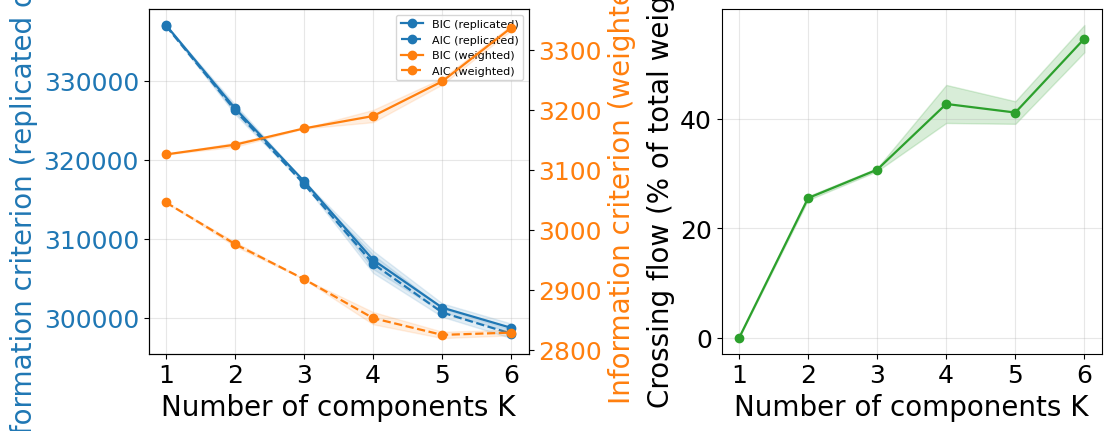

In [13]:
from mobility import model_selection as ms

# --- Run the K sweep ---
df_runs = ms.evaluate_n_components(
    df_edges_full,
    K_values=(1, 2, 3, 4, 5, 6),
    n_seeds=20,
    n_init=3,
    base_seed=0,
    verbose=True,
)

# Save per-run results for inspection
df_runs.to_csv(TABLES_DIR / "gmm_model_selection_runs.csv", index=False)

# Aggregated summary by K
df_summary = ms.summarize_selection(df_runs)
df_summary.to_csv(TABLES_DIR / "gmm_model_selection_summary.csv", index=False)

# --- Winning K per criterion ---
print("Winning K per criterion:\n")

# BIC/AIC: K=1 är giltigt (baseline med en gaussian)
for crit in ["bic_rep", "aic_rep", "bic_w", "aic_w"]:
    res = ms.winning_K(df_runs, criterion=crit)
    print(f"  {crit:14s}: best_by_mean = K={res['best_by_mean']}, "
          f"per-seed votes = {res['vote_counts_per_seed']}")

# flow_between och silhouette: K=1 är trivialt/odefinierat
for crit in ["flow_between", "silhouette"]:
    res = ms.winning_K(df_runs, criterion=crit, exclude_K=(1,))
    print(f"  {crit:14s}: best_by_mean = K={res['best_by_mean']}, "
          f"per-seed votes = {res['vote_counts_per_seed']}  "
          f"(K=1 excluded)")

# --- Compact summary table ---
display_cols = ["K", "bic_rep_mean", "aic_rep_mean",
                "bic_w_mean", "aic_w_mean",
                "flow_between_mean", "min_sys_frac_mean",
                "silhouette_mean"]
display(df_summary[display_cols].round(2))

# --- Curve shape: marginal improvement per K step ---
print("\nMarginal improvement of BIC_w per K step:")
print(ms.relative_improvement(df_runs, "bic_w").round(2).to_string(index=False))

print("\nMarginal improvement of AIC_w per K step:")
print(ms.relative_improvement(df_runs, "aic_w").round(2).to_string(index=False))

print("\nflow_between mean by K (K=1 trivially 0):")
print(df_summary[["K", "flow_between_mean", "flow_between_std",
                  "min_sys_frac_mean"]].round(2).to_string(index=False))

# --- Elbow plot ---
fig = ms.plot_model_selection(
    df_runs,
    out_path=FIGURES_DIR / "gmm_model_selection.pdf",
    show_flow_between=True,
)
print(f"\nSaved: {FIGURES_DIR / 'gmm_model_selection.pdf'}")

K=3 fit:
  flow_within  = 69.5%
  flow_between = 30.5%
  min_sys_frac = 12.2%

Crosstab (SOC count): K=2 rows, K=3 columns
k3_label    0   1   2
k2_label             
0         133  18  32
1          15  95   3

Crosstab (outflow weight): K=2 rows, K=3 columns
k3_label      0     1     2
k2_label                   
0         121.4  16.5  30.6
1          13.9  90.5   2.9

K=3 system characterisation:


,k3_system,n_soc,total_outflow,share_of_total,mean_xi_deg,mean_chi,top_occupations
0,0,148,135.34,49.0,329.9,0.311,"Opticians, Dispensing (29-2081); Library Techn..."
1,1,113,107.06,38.8,187.1,0.446,"Mail Clerks and Mail Machine Operators, Except..."
2,2,35,33.57,12.2,79.0,0.374,Tire Builders (51-9197); Bioengineers and Biom...



Saved: /home/joc/code/two-scales-of-mobility/outputs/figures/k2_vs_k3_geography.pdf


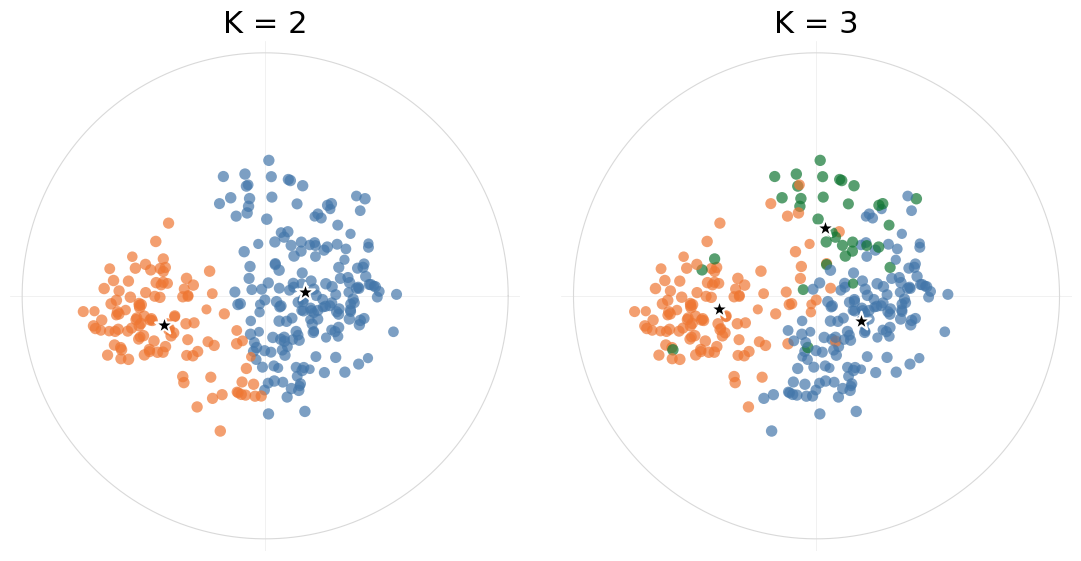

In [14]:
from mobility import k3_comparison as k3
from mobility.systems import attractor_poles

# --- Fit K=3 GMM ---
best_k3, runs_k3 = k3.run_k3(
    df_edges_full,
    n_runs=5,
    n_init=5,
    base_seed=0,
)
print(f"K=3 fit:")
print(f"  flow_within  = {best_k3.flow_within:.1f}%")
print(f"  flow_between = {best_k3.flow_between:.1f}%")
print(f"  min_sys_frac = {best_k3.min_sys_frac:.1f}%")

# --- Crosstab: where do K=2 SOCs go in K=3? ---
n_tab, w_tab = k3.crosstab_k2_vs_k3(
    soc_system_k2=best.soc_system,
    soc_system_k3=best_k3.soc_system,
    df_edges=df_edges_full,
)
print("\nCrosstab (SOC count): K=2 rows, K=3 columns")
print(n_tab)
print("\nCrosstab (outflow weight): K=2 rows, K=3 columns")
print(w_tab.round(1))

# --- Characterise the three K=3 systems ---
title_map = (
    df_occ.dropna(subset=["soc2018", "Title"])
          .groupby("soc2018")["Title"]
          .first()
)
df_k3_char = k3.characterise_k3_systems(
    soc_system_k3=best_k3.soc_system,
    df_soc_centres=df_soc_centres,
    df_edges=df_edges_full,
    title_map=title_map,
    n_top=8,
)
print("\nK=3 system characterisation:")
display(df_k3_char)
df_k3_char.to_csv(TABLES_DIR / "k3_system_characterisation.csv", index=False)

# --- Compute poles for both partitions locally ---
poles_k2 = attractor_poles(df_edges_full, best.soc_system, best.n_components)
poles_k3 = attractor_poles(df_edges_full, best_k3.soc_system, 3)

# --- Geographic plot ---
fig = k3.plot_k3_geography(
    soc_system_k3=best_k3.soc_system,
    soc_system_k2=best.soc_system,
    df_soc_centres=df_soc_centres,
    df_edges=df_edges_full,
    poles_k3=poles_k3,
    poles_k2=poles_k2,
    out_path=FIGURES_DIR / "k2_vs_k3_geography.pdf",
)
print(f"\nSaved: {FIGURES_DIR / 'k2_vs_k3_geography.pdf'}")

K=2: flow_within=74.3%, flow_between=25.7%, min_sys_frac=38.9%
K=3: flow_within=69.5%, flow_between=30.5%, min_sys_frac=12.2%
K=4: flow_within=62.0%, flow_between=38.0%, min_sys_frac=10.0%
K=5: flow_within=60.2%, flow_between=39.8%, min_sys_frac=7.3%
K=6: flow_within=46.0%, flow_between=54.0%, min_sys_frac=8.0%

=== K = 2 ===


,system,n_soc,share_of_total,mean_xi_deg,mean_chi,top_occupations
0,0,183,61.1,358.0,0.302,"Library Technicians; Opticians, Dispensing; Bi..."
1,1,113,38.9,197.9,0.480,"Mail Clerks and Mail Machine Operators, Except..."



=== K = 3 ===


,system,n_soc,share_of_total,mean_xi_deg,mean_chi,top_occupations
0,0,148,49.0,329.9,0.311,"Opticians, Dispensing; Library Technicians; Nu..."
1,1,113,38.8,187.1,0.446,"Mail Clerks and Mail Machine Operators, Except..."
2,2,35,12.2,79.0,0.374,Tire Builders; Bioengineers and Biomedical Eng...



=== K = 4 ===


...


=== K = 5 ===


,system,n_soc,share_of_total,mean_xi_deg,mean_chi,top_occupations
0,0,29,10.1,70.0,0.383,Computer and Information Research Scientists; ...
1,1,22,7.3,114.1,0.224,Security and Fire Alarm Systems Installers; Pa...
2,2,62,21.4,188.2,0.528,Automotive Glass Installers and Repairers; Hel...
3,3,159,52.9,322.0,0.307,"Mail Clerks and Mail Machine Operators, Except..."
4,4,24,8.4,185.6,0.484,Laundry and Dry-Cleaning Workers; Food and Tob...



=== K = 6 ===


,system,n_soc,share_of_total,mean_xi_deg,mean_chi,top_occupations
0,0,65,22.4,189.6,0.520,Automotive Glass Installers and Repairers; Hel...
1,1,31,10.4,143.9,0.230,Economists; Parking Enforcement Workers; Cargo...
2,2,32,11.1,64.5,0.379,Computer and Information Research Scientists; ...
3,3,96,31.5,348.7,0.297,Radiation Therapists; Nurse Practitioners; Fir...
4,4,23,8.0,184.3,0.488,Laundry and Dry-Cleaning Workers; Food and Tob...
5,5,49,16.6,279.5,0.336,"Library Technicians; Opticians, Dispensing; Ma..."



Saved: /home/joc/code/two-scales-of-mobility/outputs/figures/k_sweep_geography.pdf


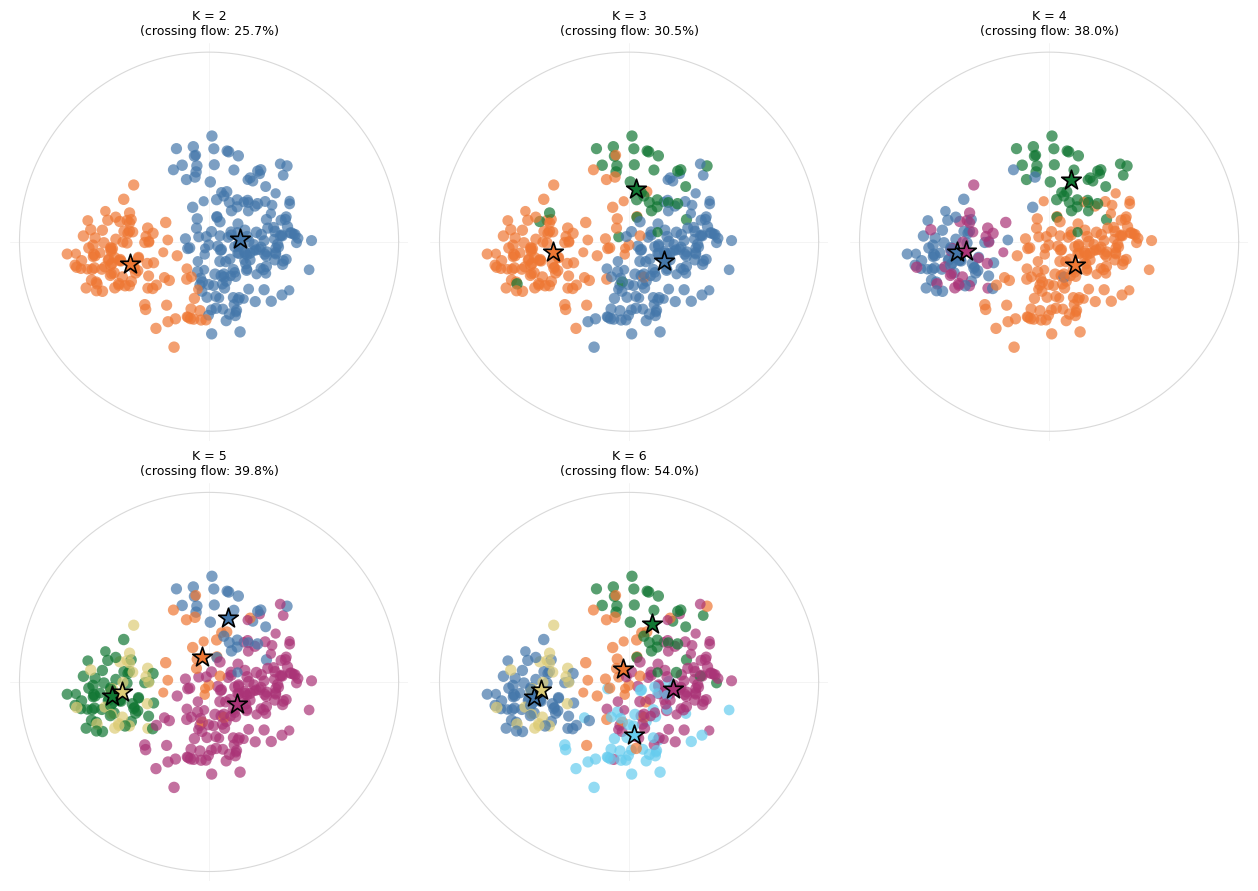

In [15]:
from mobility import k_sweep as ks

# --- Run GMM for K = 2..6 ---
assignments = ks.run_k_sweep(
    df_edges_full,
    K_values=(2, 3, 4, 5, 6),
    n_runs=5,
    n_init=5,
    base_seed=0,
)

# --- Characterise each K's systems (saved as CSVs for inspection) ---
title_map = (
    df_occ.dropna(subset=["soc2018", "Title"])
          .groupby("soc2018")["Title"]
          .first()
)
for K, assignment in assignments.items():
    df_char = ks.characterise_systems(
        soc_system=assignment.soc_system,
        df_soc_centres=df_soc_centres,
        df_edges=df_edges_full,
        title_map=title_map,
        n_top=5,
    )
    print(f"\n=== K = {K} ===")
    display(df_char)
    df_char.to_csv(
        TABLES_DIR / f"k_sweep_characterisation_K{K}.csv",
        index=False,
    )

# --- Small-multiples grid ---
fig = ks.plot_k_sweep_grid(
    assignments=assignments,
    df_soc_centres=df_soc_centres,
    df_edges=df_edges_full,
    out_path=FIGURES_DIR / "k_sweep_geography.pdf",
    n_cols=3,
)
print(f"\nSaved: {FIGURES_DIR / 'k_sweep_geography.pdf'}")

Mobility cost as function of K (pooled):

 K  flow_within  flow_between  within_median_uR  crossing_median_uR  cost_ratio
 2       74.315        25.685             0.814               1.926       2.365
 3       69.474        30.526             0.806               1.789       2.219
 4       61.959        38.041             0.791               1.672       2.115
 5       60.221        39.779             0.787               1.631       2.072
 6       46.034        53.966             0.728               1.437       1.974

Per-system within-mobility median u_R:



,K,system,n_edges,w_sum,share_of_within,median_uR,p25_uR,p75_uR
0,2,0,5363,140.407,0.685,0.898,0.542,1.305
1,2,1,1594,64.680,0.315,0.670,0.419,1.072
2,3,0,4105,107.517,0.561,0.868,0.529,1.274
3,3,1,1622,68.414,0.357,0.715,0.447,1.205
4,3,2,328,15.795,0.082,0.784,0.419,1.157
5,4,0,517,28.816,0.169,0.547,0.392,0.974
6,4,1,4530,118.083,0.691,0.860,0.534,1.264
7,4,2,495,19.494,0.114,0.745,0.410,1.022
8,4,3,109,4.594,0.027,0.579,0.381,0.710
9,5,0,302,15.260,0.092,0.682,0.388,1.022



Saved: /home/joc/code/two-scales-of-mobility/outputs/figures/cost_by_K.pdf


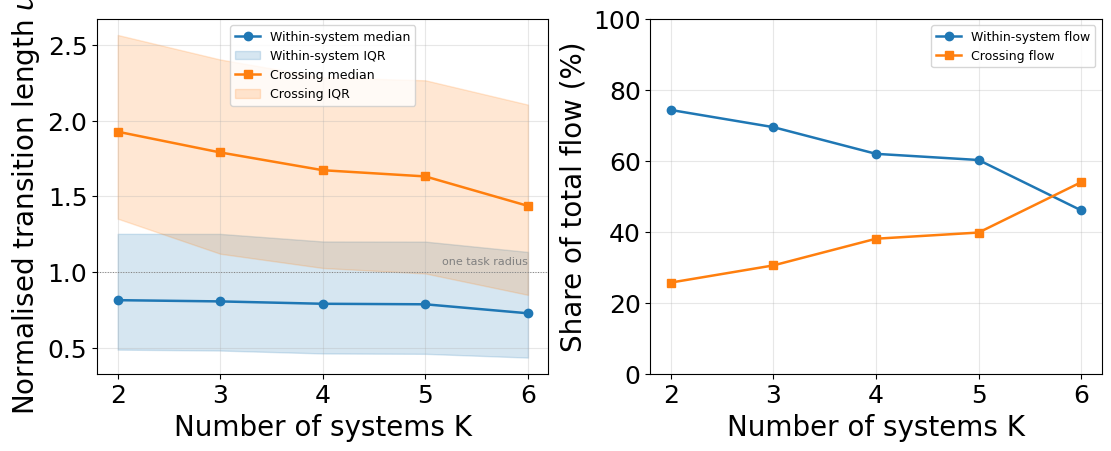

In [16]:
from mobility import k_cost_analysis as kc

# --- Pooled cost stats per K ---
df_cost = kc.cost_by_K(assignments, df_edges_full)
print("Mobility cost as function of K (pooled):\n")
print(df_cost[["K", "flow_within", "flow_between",
               "within_median_uR", "crossing_median_uR",
               "cost_ratio"]].round(3).to_string(index=False))

df_cost.to_csv(TABLES_DIR / "cost_by_K.csv", index=False)

# --- Per-system breakdown ---
df_cost_sys = kc.cost_per_system(assignments, df_edges_full)
print("\nPer-system within-mobility median u_R:\n")
display(df_cost_sys.round(3))
df_cost_sys.to_csv(TABLES_DIR / "cost_per_system.csv", index=False)

# --- Plot ---
fig = kc.plot_cost_by_K(
    df_cost,
    out_path=FIGURES_DIR / "cost_by_K.pdf",
)
print(f"\nSaved: {FIGURES_DIR / 'cost_by_K.pdf'}")

Job Family table: 765 SOCs, 22 distinct families

Family distribution:
job_family
Production                                        101
Healthcare Practitioners and Technical             63
Educational Instruction and Library                61
Construction and Extraction                        58
Installation, Maintenance, and Repair              50
Office and Administrative Support                  49
Life, Physical, and Social Science                 45
Transportation and Material Moving                 44
Management                                         34
Arts, Design, Entertainment, Sports, and Media     33
Business and Financial Operations                  31
Architecture and Engineering                       31
Personal Care and Service                          28
Protective Service                                 22
Computer and Mathematical                          21
Sales and Related                                  20
Healthcare Support                                 18


,system,job_family,weight,share_within_system
0,0,Office and Administrative Support,23.541999,14.0
1,0,Business and Financial Operations,19.338582,11.5
2,0,Healthcare Practitioners and Technical,19.289598,11.4
3,0,Management,18.391004,10.9
4,0,Other (18 families),88.039689,52.2
5,1,Production,35.329665,32.9
6,1,"Installation, Maintenance, and Repair",20.267001,18.9
7,1,Construction and Extraction,16.269126,15.2
8,1,Office and Administrative Support,12.269421,11.4
9,1,Other (7 families),23.232680,21.6



=== K = 3: top 4 Job Families per system ===


,system,job_family,weight,share_within_system
0,0,Office and Administrative Support,26.240576,19.4
1,0,Healthcare Practitioners and Technical,19.289598,14.3
2,0,Business and Financial Operations,16.737922,12.4
3,0,Management,13.552909,10.0
4,0,Other (13 families),59.517099,43.9
5,1,Production,34.310690,32.0
6,1,"Installation, Maintenance, and Repair",20.261304,18.9
7,1,Construction and Extraction,18.118811,16.9
8,1,Transportation and Material Moving,11.231370,10.5
9,1,Other (10 families),23.133802,21.7



=== K = 4: top 4 Job Families per system ===


...


=== K = 5: top 4 Job Families per system ===


,system,job_family,weight,share_within_system
0,0,Architecture and Engineering,10.770765,38.7
1,0,Computer and Mathematical,9.487678,34.1
2,0,Management,1.944653,7.0
3,0,"Life, Physical, and Social Science",1.927699,6.9
4,0,Other (4 families),3.688779,13.3
5,1,Business and Financial Operations,3.522541,17.6
6,1,Management,2.893443,14.4
7,1,Protective Service,2.889800,14.4
8,1,"Installation, Maintenance, and Repair",1.972959,9.8
9,1,Other (7 families),8.769974,43.7



=== K = 6: top 4 Job Families per system ===


,system,job_family,weight,share_within_system
0,0,Production,19.835447,32.1
1,0,"Installation, Maintenance, and Repair",15.355476,24.8
2,0,Construction and Extraction,15.316838,24.8
3,0,Transportation and Material Moving,7.535447,12.2
4,0,Other (2 families),3.830064,6.2
5,1,Office and Administrative Support,4.711999,16.4
6,1,Protective Service,3.847598,13.4
7,1,Business and Financial Operations,3.522541,12.3
8,1,Management,2.893443,10.1
9,1,Other (7 families),13.721135,47.7



Saved heatmaps for K=2 and K=6


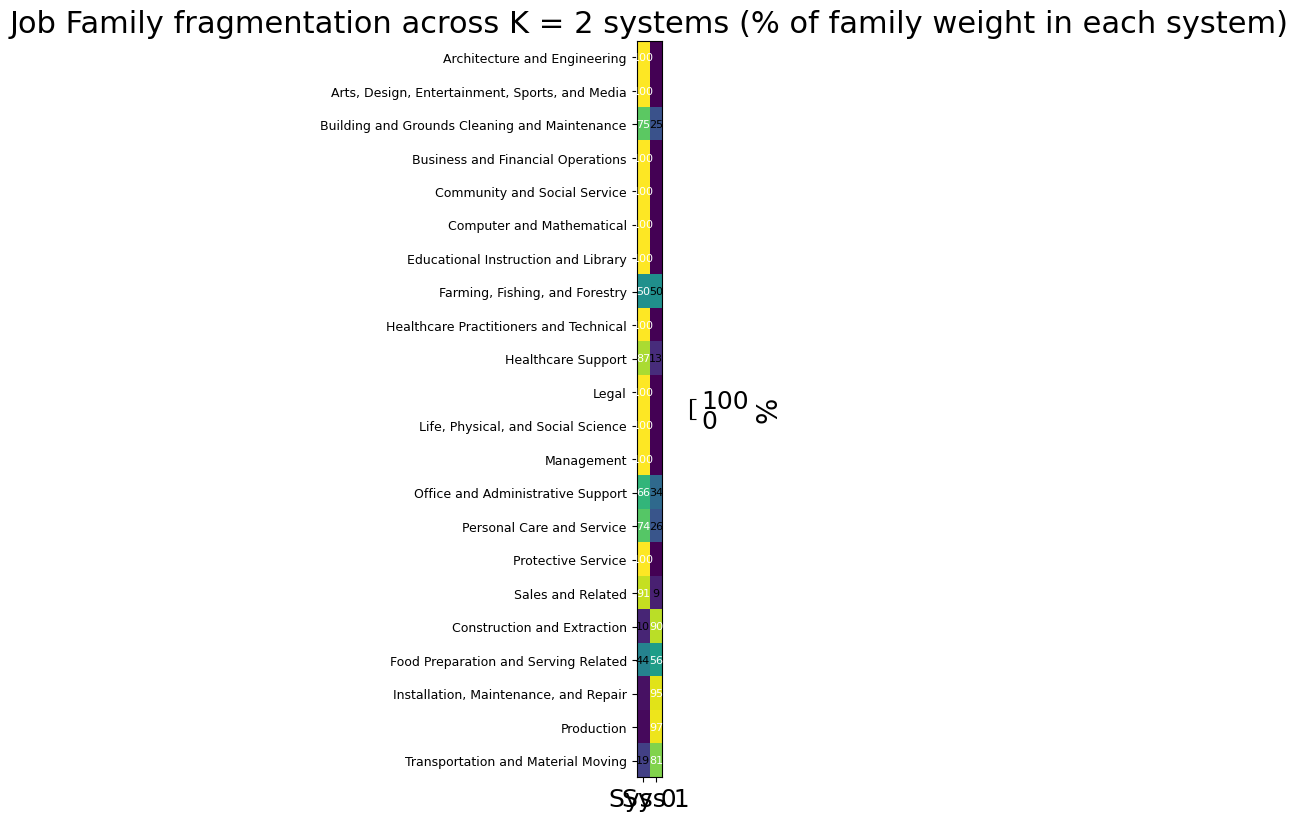

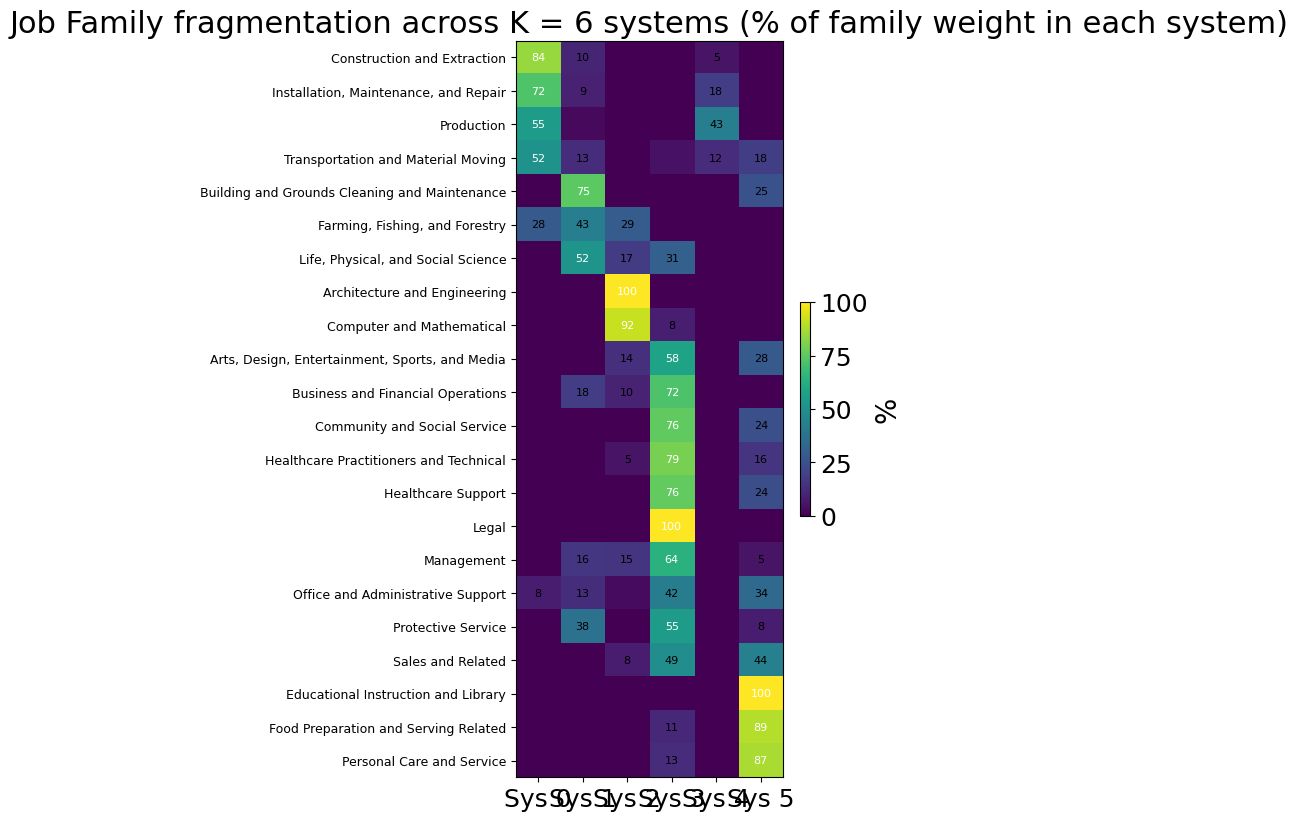

In [17]:
from mobility import job_families as jf

# --- Load Job Family table, restricted to SOCs in our data ---
df_jobfam = jf.load_job_families(
    DATA_DIR / "onet" / "All_Job_Families.csv",
    df_soc_centres=df_soc_centres,
)
print(f"Job Family table: {len(df_jobfam)} SOCs, "
      f"{df_jobfam['job_family'].nunique()} distinct families")
print(f"\nFamily distribution:")
print(df_jobfam["job_family"].value_counts().to_string())

# --- Agreement as function of K ---
df_agreement = jf.agreement_by_K(assignments, df_jobfam)
print(f"\nGMM vs Job Family agreement across K:")
print(df_agreement.round(3).to_string(index=False))
df_agreement.to_csv(TABLES_DIR / "jobfam_agreement_by_K.csv", index=False)

# --- For each K, system composition and family fragmentation ---
for K, assignment in assignments.items():
    print(f"\n=== K = {K}: top 4 Job Families per system ===")
    comp = jf.system_composition(
        assignment.soc_system, df_jobfam, df_edges_full,
        weight_by_outflow=True, top_n=4,
    )
    display(comp)
    comp.to_csv(TABLES_DIR / f"jobfam_composition_K{K}.csv", index=False)

# --- Composition heatmaps for K=2 and K=6 ---
for K in [2, 6]:
    matrix = jf.composition_matrix(
        assignments[K].soc_system, df_jobfam, df_edges_full,
        weight_by_outflow=True, normalise="family",
    )
    fig = jf.plot_composition_heatmap(
        matrix,
        title=f"Job Family fragmentation across K = {K} systems "
              f"(% of family weight in each system)",
        out_path=FIGURES_DIR / f"jobfam_composition_K{K}.pdf",
    )
print(f"\nSaved heatmaps for K=2 and K=6")

In [18]:
from mobility import jobfam_global_tables as jgt

# --- Build one table per K with global shares ---
tables = jgt.all_global_share_tables(
    assignments=assignments,
    df_jobfam=df_jobfam,
    df_edges=df_edges_full,
    weight_by_outflow=True,
    round_to=2,
    sort_families_by="row_total",
)

# --- Display each one ---
for K, df in tables.items():
    print(f"\n=== K = {K}: % of total mobility weight ===")
    display(df)

# --- Save to CSVs ---
jgt.save_tables_to_csv(tables, TABLES_DIR, prefix="jobfam_global_K")


=== K = 2: % of total mobility weight ===


,Sys 0,Sys 1,TOTAL
Job Family,,,
Production,0.34,12.80,13.14
Office and Administrative Support,8.53,4.45,12.98
"Installation, Maintenance, and Repair",0.35,7.34,7.69
Business and Financial Operations,7.01,0.00,7.01
Healthcare Practitioners and Technical,6.99,0.00,6.99
Management,6.66,0.00,6.66
Construction and Extraction,0.67,5.90,6.57
Transportation and Material Moving,1.00,4.30,5.30
Architecture and Engineering,3.90,0.00,3.90



=== K = 3: % of total mobility weight ===


,Sys 0,Sys 1,Sys 2,TOTAL
Job Family,,,,
Production,0.00,12.43,0.71,13.14
Office and Administrative Support,9.51,2.78,0.68,12.97
"Installation, Maintenance, and Repair",0.00,7.34,0.35,7.69
Business and Financial Operations,6.07,0.63,0.31,7.01
Healthcare Practitioners and Technical,6.99,0.00,0.00,6.99
Management,4.91,0.70,1.06,6.67
Construction and Extraction,0.00,6.57,0.00,6.57
Transportation and Material Moving,1.23,4.07,0.00,5.30
Architecture and Engineering,0.00,0.00,3.90,3.90



=== K = 4: % of total mobility weight ===


...


=== K = 5: % of total mobility weight ===


,Sys 0,Sys 1,Sys 2,Sys 3,Sys 4,TOTAL
Job Family,,,,,,
Production,0.00,0.34,7.19,0.00,5.61,13.14
Office and Administrative Support,0.36,0.32,0.35,11.62,0.33,12.98
"Installation, Maintenance, and Repair",0.00,0.71,5.56,0.00,1.42,7.69
Business and Financial Operations,0.33,1.28,0.00,5.40,0.00,7.01
Healthcare Practitioners and Technical,0.00,0.00,0.00,6.99,0.00,6.99
Management,0.70,1.05,0.00,4.91,0.00,6.66
Construction and Extraction,0.00,0.67,5.55,0.00,0.35,6.57
Transportation and Material Moving,0.00,0.34,2.38,1.92,0.66,5.30
Architecture and Engineering,3.90,0.00,0.00,0.00,0.00,3.90



=== K = 6: % of total mobility weight ===


,Sys 0,Sys 1,Sys 2,Sys 3,Sys 4,Sys 5,TOTAL
Job Family,,,,,,,
Production,7.19,0.34,0.00,0.00,5.61,0.00,13.14
Office and Administrative Support,1.04,1.71,0.36,5.43,0.00,4.44,12.98
"Installation, Maintenance, and Repair",5.56,0.71,0.00,0.00,1.42,0.00,7.69
Business and Financial Operations,0.00,1.28,0.68,5.05,0.00,0.00,7.01
Healthcare Practitioners and Technical,0.00,0.00,0.36,5.54,0.00,1.09,6.99
Management,0.00,1.05,1.02,4.24,0.00,0.35,6.66
Construction and Extraction,5.55,0.67,0.00,0.00,0.35,0.00,6.57
Transportation and Material Moving,2.73,0.68,0.00,0.25,0.66,0.98,5.30
Architecture and Engineering,0.00,0.00,3.90,0.00,0.00,0.00,3.90


  Saved: /home/joc/code/two-scales-of-mobility/outputs/tables/jobfam_global_K2.csv
  Saved: /home/joc/code/two-scales-of-mobility/outputs/tables/jobfam_global_K3.csv
  Saved: /home/joc/code/two-scales-of-mobility/outputs/tables/jobfam_global_K4.csv
  Saved: /home/joc/code/two-scales-of-mobility/outputs/tables/jobfam_global_K5.csv
  Saved: /home/joc/code/two-scales-of-mobility/outputs/tables/jobfam_global_K6.csv


In [19]:
from mobility import hierarchy_table as ht

# Build the summary (with Job Family hint for the smallest system)
df_hier = ht.hierarchy_summary(
    assignments=assignments,
    df_jobfam=df_jobfam,
    df_edges=df_edges_full,
)
print("Hierarchy summary (narrative column to be filled in):\n")
display(df_hier)

# Save CSV — fill in narrative column in a spreadsheet editor or manually
df_hier.to_csv(TABLES_DIR / "hierarchy_summary.csv", index=False)
print(f"\nSaved: {TABLES_DIR / 'hierarchy_summary.csv'}")

# LaTeX preview (with empty narrative cells — fill them in before pasting)
latex = ht.to_latex_table(df_hier, include_hint=True)
print("\nLaTeX preview:\n")
print(latex)

Hierarchy summary (narrative column to be filled in):



,K,n_systems,crossing_flow_pct,smallest_system_pct,hint_smallest_top_family,narrative
0,2,2,25.7,38.9,Production (33%),
1,3,3,30.5,12.2,Architecture and Engineering (32%),
2,4,4,38.0,10.0,Production (63%),
3,5,5,39.8,7.3,Business and Financial Operations (18%),
4,6,6,54.0,8.0,Production (70%),



Saved: /home/joc/code/two-scales-of-mobility/outputs/tables/hierarchy_summary.csv

LaTeX preview:

\begin{table}[!htbp]
\centering
\caption{Hierarchical structure of mobility segmentation. Each row shows the partition produced by GMM with K subsystems, the share of total mobility weight that crosses subsystem boundaries, and the size of the smallest subsystem. The final column describes the new functional structure that emerges at that level.}
\label{tab:hierarchy}
\begin{tabular}{ccccp{6.5cm}}
\toprule
K & Crossing flow (\%) & Smallest system (\%) & Smallest system's top family & Emerging functional structure \\
\midrule
2 & 25.7 & 38.9 & Production (33%) &  \\
3 & 30.5 & 12.2 & Architecture and Engineering (32%) &  \\
4 & 38.0 & 10.0 & Production (63%) &  \\
5 & 39.8 & 7.3 & Business and Financial Operations (18%) &  \\
6 & 54.0 & 8.0 & Production (70%) &  \\
\bottomrule
\end{tabular}
\end{table}


In [20]:
from mobility import jobfam_global_tables as jgt

# --- Summary table: dominant share per family across K-values ---
df_coh = jgt.coherence_summary(
    assignments=assignments,
    df_jobfam=df_jobfam,
    df_edges=df_edges_full,
    weight_by_outflow=True,
    sort_by="total_share",
)
print("Job Family coherence across K (% of family weight in dominant system):\n")
display(df_coh)

df_coh.to_csv(TABLES_DIR / "jobfam_coherence_summary.csv")
print(f"\nSaved: {TABLES_DIR / 'jobfam_coherence_summary.csv'}")

Job Family coherence across K (% of family weight in dominant system):



,total_share,dom_K2,dom_K3,dom_K4,dom_K5,dom_K6
Job Family,,,,,,
Production,13.2,97.4,94.6,49.6,54.7,54.7
Office and Administrative Support,13.0,65.7,73.3,89.5,89.5,41.8
"Installation, Maintenance, and Repair",7.7,95.4,95.4,72.3,72.3,72.3
Healthcare Practitioners and Technical,7.0,100.0,100.0,100.0,100.0,79.3
Business and Financial Operations,7.0,100.0,86.6,77.5,77.1,72.1
Management,6.7,100.0,73.7,69.0,73.7,63.7
Construction and Extraction,6.6,89.8,100.0,90.0,84.5,84.5
Transportation and Material Moving,5.3,81.0,76.8,44.8,45.0,51.5
Architecture and Engineering,3.9,100.0,100.0,100.0,100.0,100.0



Saved: /home/joc/code/two-scales-of-mobility/outputs/tables/jobfam_coherence_summary.csv


In [21]:
src_sys, tgt_sys, crossing = msys.assign_edge_systems(
    df_edges_full, best.soc_system,
)

# Per-system fields: edges where both endpoints are in system k
field_systems = {}
for k in range(best.n_components):
    mask_k = (src_sys == k) & (tgt_sys == k)
    field_systems[k] = mfields.compute_or_load(
        name=f"system_{k}",
        edges=edges_arrays, grid=grid, cfg=field_cfg,
        cache_dir=cache_dir,
        edge_mask=mask_k,
    )
    print(f"System {k}: {int(mask_k.sum())} within-edges")

# Crossing field
field_crossing = mfields.compute_or_load(
    name="crossing",
    edges=edges_arrays, grid=grid, cfg=field_cfg,
    cache_dir=cache_dir,
    edge_mask=crossing,
)
print(f"Crossing  : {int(crossing.sum())} edges")

# Attractor poles and dynamic separatrix
poles = msys.attractor_poles(df_edges_full, best.soc_system,
                              best.n_components)
print(f"\nPoles:")
for k, p in enumerate(poles):
    angle = np.degrees(np.arctan2(p[1], p[0])) % 360
    print(f"  Pole {k}: ({p[0]:+.3f}, {p[1]:+.3f})  angle={angle:.1f}°")

separatrix = msys.dynamic_separatrix(
    edges_arrays, grid, field_cfg, crossing, poles,
)

System 0: 5363 within-edges
System 1: 1594 within-edges
Crossing  : 3594 edges

Poles:
  Pole 0: (+0.166, +0.014)  angle=4.8°
  Pole 1: (-0.418, -0.120)  angle=196.0°


In [22]:
from mobility import plots

# Background occupations: original O*NET-detailed positions
xo = df_occ["x"].to_numpy()
yo = df_occ["y"].to_numpy()

plots.plot_mobility_systems_combined(
    field_systems=field_systems,
    field_residual=field_crossing,
    field_global=field_global,
    grid=grid,
    separatrix=separatrix,
    poles=poles,
    occupations_xy=(xo, yo),
    out_path=FIGURES_DIR / "mobility_systems_combined.png",
    theme="paper",
)
print(f"Saved: {FIGURES_DIR / 'mobility_systems_combined.png'}")

Saved: /home/joc/code/two-scales-of-mobility/outputs/figures/mobility_systems_combined.png


In [23]:
edge_subsets = msys.partition_edges_by_system(
    df_edges_full, best.soc_system, best.n_components,
)

print("Edge subset sizes:")
for key, sub in edge_subsets.items():
    print(f"  {key:12s}: {len(sub):5d} edges, w_sum={sub['wP'].sum():.2f}")

# Compute and print median normalised hop length per subset
print("\nMedian u_R per subset:")
for key, sub in edge_subsets.items():
    u = sub["u_R"].to_numpy(dtype=float)
    w = sub["wP"].to_numpy(dtype=float)
    print(f"  {key:12s}: median u_R = {stats.wquantile(u, w, 0.50):.3f}")

plots.plot_system_cdfs(
    edge_subsets=edge_subsets,
    out_path=FIGURES_DIR / "transition_length_cdf_normalised.png",
    theme="paper",
)
print(f"\nSaved: {FIGURES_DIR / 'transition_length_cdf_normalised.png'}")

Edge subset sizes:
  within_0    :  5363 edges, w_sum=140.41
  within_1    :  1594 edges, w_sum=64.68
  crossing    :  3594 edges, w_sum=70.88

Median u_R per subset:
  within_0    : median u_R = 0.898
  within_1    : median u_R = 0.670
  crossing    : median u_R = 1.926

Saved: /home/joc/code/two-scales-of-mobility/outputs/figures/transition_length_cdf_normalised.png


In [24]:
from mobility import directions as mdir

# Project displacement onto tangential direction at source
edge_subsets_proj = {}
for key, sub in edge_subsets.items():
    edge_subsets_proj[key] = mdir.compute_tangential_projection(
        sub, df_soc_centres, normalise=True,
    )

# Compute angular curves per subset
curves = {}
for key, sub in edge_subsets_proj.items():
    bin_centres, curve, se, weights = mdir.angular_curve(
        sub, n_bins=36, smooth_window=3,
    )
    curves[key] = (bin_centres, curve, se, weights)
    n_valid = int(np.isfinite(curve).sum())
    mean_proj = float(np.nanmean(curve))
    mean_se = float(np.nanmean(se))
    print(f"  {key:12s}: {n_valid}/36 bins, "
          f"mean proj_xi={mean_proj:+.3f}, mean SE={mean_se:.3f}")

# Plot without bands (default)
plots.plot_angular_directions(
    curves=curves,
    out_path=FIGURES_DIR / "mobility_directions_by_system.png",
    poles=poles,
    pole_labels=[f"Pole {i}" for i in range(best.n_components)],
    theme="paper",
    origin_deg=135.0,
)
print(f"Saved: {FIGURES_DIR / 'mobility_directions_by_system.png'}")

# Plot with bands (alternative version)
plots.plot_angular_directions(
    curves=curves,
    out_path=FIGURES_DIR / "mobility_directions_by_system_with_band.png",
    poles=poles,
    pole_labels=[f"Pole {i}" for i in range(best.n_components)],
    theme="paper",
    origin_deg=135.0,
    show_band=True,
    band_n_se=1.0,
    band_alpha=0.18,
)
print(f"Saved: {FIGURES_DIR / 'mobility_directions_by_system_with_band.png'}")

  within_0    : 29/36 bins, mean proj_xi=+0.015, mean SE=0.102
  within_1    : 13/36 bins, mean proj_xi=-0.015, mean SE=0.103
  crossing    : 35/36 bins, mean proj_xi=+0.013, mean SE=0.072
Saved: /home/joc/code/two-scales-of-mobility/outputs/figures/mobility_directions_by_system.png
Saved: /home/joc/code/two-scales-of-mobility/outputs/figures/mobility_directions_by_system_with_band.png


In [25]:
plots.plot_gmm_diagnostic(
    df_edges=df_edges_full,
    soc_system=best.soc_system,
    poles=poles,
    grid=grid,
    separatrix=separatrix,
    occupations_xy=(xo, yo),
    out_path=FIGURES_DIR / "gmm_4d_systems.png",
    flow_within_pct=best.flow_within,
    flow_between_pct=best.flow_between,
    theme="presentation",
)
print(f"Saved: {FIGURES_DIR / 'gmm_4d_systems.png'}")

Saved: /home/joc/code/two-scales-of-mobility/outputs/figures/gmm_4d_systems.png


In [26]:
plots.plot_mobility_field_combined(
    field_systems=field_systems,
    grid=grid,
    separatrix=separatrix,
    poles=poles,
    occupations_xy=(xo, yo),
    out_path=FIGURES_DIR / "mobility_field_combined.png",
    sys_labels={0: "System 0 (cognitive)", 1: "System 1 (physical)"},
    theme="presentation",
)
print(f"Saved: {FIGURES_DIR / 'mobility_field_combined.png'}")

plots.plot_mobility_field_residual(
    field_residual=field_crossing,
    grid=grid,
    separatrix=separatrix,
    poles=poles,
    occupations_xy=(xo, yo),
    out_path=FIGURES_DIR / "mobility_field_residual.png",
    theme="presentation",
)
print(f"Saved: {FIGURES_DIR / 'mobility_field_residual.png'}")

Saved: /home/joc/code/two-scales-of-mobility/outputs/figures/mobility_field_combined.png
Saved: /home/joc/code/two-scales-of-mobility/outputs/figures/mobility_field_residual.png


Saved: /home/joc/code/two-scales-of-mobility/outputs/figures/mobility_fields_K4.png


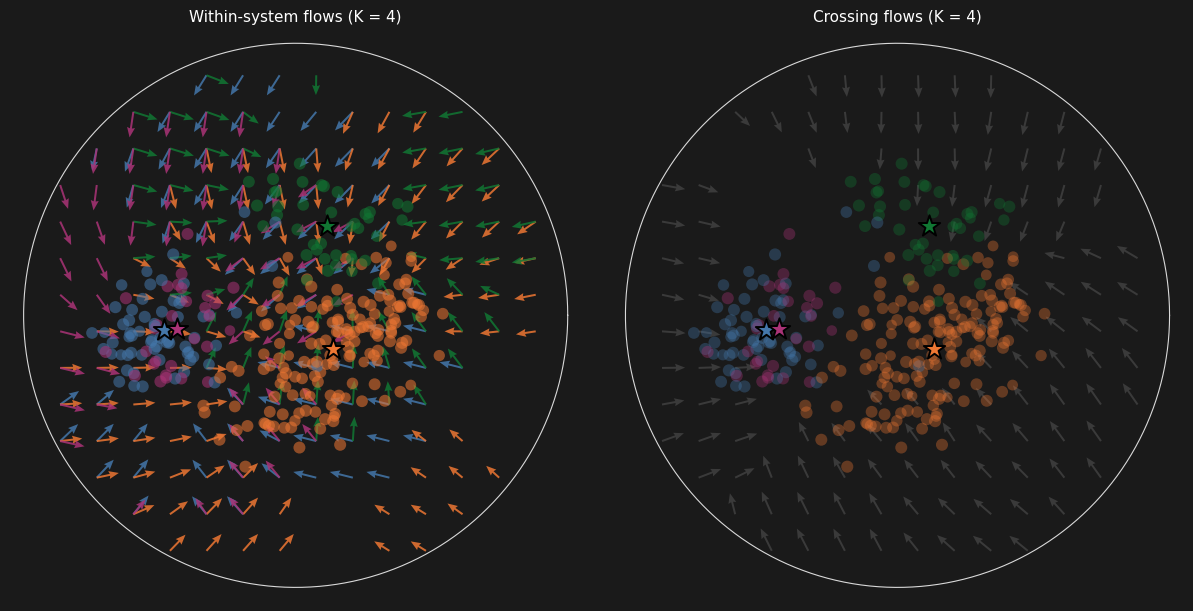

In [27]:
from mobility import k_fields_plot as kfp

# Pick K to visualise
K_pick = 4

cache_dir = OUTPUTS_DIR / "field_cache"

fields_data = kfp.compute_fields_for_K(
    df_edges=df_edges_full,
    assignment=assignments[K_pick],
    bandwidth=0.08,
    n_grid=120,
    cache_dir=cache_dir,
)

fig = kfp.plot_mobility_fields_K(
    fields_data=fields_data,
    df_soc_centres=df_soc_centres,
    assignment=assignments[K_pick],
    df_edges=df_edges_full,
    out_path=FIGURES_DIR / f"mobility_fields_K{K_pick}.png",
    arrow_stride=8,
)
print(f"Saved: {FIGURES_DIR / f'mobility_fields_K{K_pick}.png'}")

In [28]:
from mobility import diagnostics as mdiag

# Build a SOC -> title map from the occupation table
title_map = (
    df_occ.dropna(subset=["soc2018", "Title"])
          .groupby("soc2018")["Title"]
          .first()
)

# Take crossing edges and add u_R for the summary table
df_edges_crossing = edge_subsets["crossing"].copy()

# Classify each crossing edge by manager-direction and segment
df_edges_classified = mdiag.classify_subgroups(
    df_edges_crossing=df_edges_crossing,
    df_soc_centres=df_soc_centres,
    title_map=title_map,
)

print("Subgroup edge counts:")
counts = df_edges_classified["subgroup"].value_counts()
for sg in mdiag.SUBGROUP_ORDER:
    if sg in counts.index:
        n = int(counts[sg])
        w = float(df_edges_classified.loc[
            df_edges_classified["subgroup"] == sg, "wP"
        ].sum())
        print(f"  {sg:30s}: n={n:5d}, w_sum={w:6.2f}")

# Source-position aggregation (used by the detailed plot)
src_positions = mdiag.source_positions_by_subgroup(
    df_edges_classified=df_edges_classified,
    df_soc_centres=df_soc_centres,
    title_map=title_map,
)

# Subgroup-level summary table (paper appendix material)
df_subgroup_summary = mdiag.subgroup_summary(df_edges_classified)
display(df_subgroup_summary)

df_subgroup_summary.to_csv(
    TABLES_DIR / "residual_subgroup_summary.csv", index=False,
)
print(f"Saved: {TABLES_DIR / 'residual_subgroup_summary.csv'}")

# Source x target sector flow matrix (non-managers)
flow_matrix = mdiag.non_manager_flow_matrix(
    df_edges_classified, df_soc_centres,
    column_normalise=True,
)
print("\nNon-manager flows: source-sector share by target-sector (%)")
display(flow_matrix)
flow_matrix.to_csv(TABLES_DIR / "residual_nonmgr_flow_matrix.csv")

Subgroup edge counts:
  Upward (-> mgr)               : n=  581, w_sum= 14.86
  Downward (mgr ->)             : n=  600, w_sum=  6.43
  Non-mgr W->S (CCW)            : n= 1049, w_sum= 23.67
  Non-mgr S->NE (CW)            : n=  761, w_sum= 13.11
  Non-mgr NE->NW (CCW)          : n=  318, w_sum=  6.34
  Non-mgr NW->W (CCW)           : n=  285, w_sum=  6.47


,Subgroup,n_edges,w_sum,n_src_occ,n_tgt_occ,src_centroid,tgt_centroid,arrow_len,spread,median_uR
0,Upward (-> mgr),581,14.9,101,35,W (194 deg),E (4 deg),0.526,0.253,1.984
1,Downward (mgr ->),600,6.4,34,99,E (16 deg),SW (204 deg),0.502,0.298,1.631
2,Non-mgr W->S (CCW),1049,23.7,94,173,SW (214 deg),SE (297 deg),0.382,0.325,1.875
3,Non-mgr S->NE (CW),761,13.1,80,101,SE (309 deg),SW (211 deg),0.476,0.307,2.045
4,Non-mgr NE->NW (CCW),318,6.3,38,75,N (82 deg),W (184 deg),0.554,0.238,2.139
5,Non-mgr NW->W (CCW),285,6.5,22,111,W (166 deg),NE (48 deg),0.459,0.109,1.798


Saved: /home/joc/code/two-scales-of-mobility/outputs/tables/residual_subgroup_summary.csv

Non-manager flows: source-sector share by target-sector (%)


target_sector,Sector 1 (xi 178-266 deg),Sector 2 (xi 266-34 deg),Sector 3 (xi 34-135 deg),Sector 4 (xi 135-178 deg)
source_sector,,,,
Sector 1 (xi 178-266 deg),19.6,82.0,59.2,4.8
Sector 2 (xi 266-34 deg),58.4,1.8,0.0,40.4
Sector 3 (xi 34-135 deg),19.5,0.3,0.0,52.3
Sector 4 (xi 135-178 deg),2.6,15.8,40.8,2.6


In [29]:
# Compute the synthesis (one arrow per subgroup)
df_synthesis = mdiag.flow_synthesis(df_edges_classified)

# Detailed subgroups figure
plots.plot_residual_subgroups(
    df_edges_classified=df_edges_classified,
    src_positions=src_positions,
    grid=grid,
    separatrix=separatrix,
    occupations_xy=(xo, yo),
    out_path=FIGURES_DIR / "residual_subgroups_gow.png",
    theme="paper",
)
print(f"Saved: {FIGURES_DIR / 'residual_subgroups_gow.png'}")

# Synthesis figure (one arrow per subgroup)
plots.plot_residual_synthesis(
    flow_synthesis_df=df_synthesis,
    df_edges_classified=df_edges_classified,
    grid=grid,
    separatrix=separatrix,
    occupations_xy=(xo, yo),
    out_path=FIGURES_DIR / "residual_synthesis_gow.png",
    theme="paper",
)
print(f"Saved: {FIGURES_DIR / 'residual_synthesis_gow.png'}")

Saved: /home/joc/code/two-scales-of-mobility/outputs/figures/residual_subgroups_gow.png
Saved: /home/joc/code/two-scales-of-mobility/outputs/figures/residual_synthesis_gow.png
